In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn
import scipy
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("data.csv")
df

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [6]:
#df["company"].unique()

In [7]:
#df["year"].unique()

In [8]:
#df["Price"].unique()

In [9]:
#df["kms_driven"].unique()

In [10]:
df["fuel_type"].unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [11]:
#first year Column Cleaning
df['year']=pd.to_numeric(df['year'],errors='coerce')
df.dropna(subset=['year'],inplace=True)
df['year']=df['year'].astype(int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


In [13]:
#2 Price column cleaning
for i in df.index:
    df.loc[i,'Price']=df.loc[i,'Price'].replace(',','')

In [14]:
#df['Price'].unique()

In [15]:
df['Price']=pd.to_numeric(df['Price'],errors='coerce')
df.dropna(subset=['Price'],inplace=True)
df['Price']=df['Price'].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [17]:
for i in df.index:
    df.loc[i,'kms_driven'] = df.loc[i,'kms_driven'].replace(',','')
    df.loc[i,'kms_driven'] = df.loc[i,'kms_driven'].replace('_kms','')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 77.1+ KB


In [19]:
#df['kms_driven'].unique()

In [20]:
df = df[df['kms_driven'] != 'Petrol']

In [21]:
df.dropna(subset=['kms_driven'])

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000 kms,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40 kms,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000 kms,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000 kms,Diesel
6,Ford Figo,Ford,2012,175000,41000 kms,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000 kms,Petrol
885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000 kms,Diesel
886,Toyota Corolla Altis,Toyota,2009,300000,132000 kms,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000 kms,Diesel


In [22]:
df['kms_driven'] = df['kms_driven'].str.replace(',', '', regex=False)
df['kms_driven'] = df['kms_driven'].str.replace(' kms', '', regex=False)
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')
df = df.dropna(subset=['kms_driven'])
df['kms_driven'] = df['kms_driven'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [24]:
#fuel_type cleaning column
df.dropna(inplace=True)
#only Petrol and Disel fuel_type accepted
df=df[df['fuel_type'] != 'LPG']

In [25]:
df['fuel_type'].value_counts()

fuel_type
Petrol    428
Diesel    386
Name: count, dtype: int64

In [26]:
df['fuel_type'].unique()

array(['Petrol', 'Diesel'], dtype=object)

In [27]:
df['name'].unique()

array(['Hyundai Santro Xing XO eRLX Euro III', 'Mahindra Jeep CL550 MDI',
       'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
       'Maruti Suzuki Alto K10 VXi AMT', 'Skoda Fabia Classic 1.2 MPI',
       'Maruti Suzuki Stingray VXi', 'Hyundai Elite i20 Magna 1.2',
       'Mahindra Scorpio SLE BS IV', 'Audi A8', 'Audi Q7',
       'Mahindra Scorpio S10', 'Maruti Suzuki Alto 800',
       'Maruti Suzuki Alto 800 Vxi', 'Hyundai i20 Sportz 1.2',
       'Maruti Suzuki Alto 800 Lx', 'Maruti Suzuki Vitara Brezza ZDi',
       'Maruti Suzuki Alto LX', 'Mahindra Bolero DI',
       'Maruti Suzuki Swift Dzire ZDi', 'Mahindra Scorpio S10 4WD',
       'Maruti Suzuki Swift Vdi BSIII',
       'Maruti Suzuki Wagon R VXi BS III',
       'Maruti Suzuki Wagon R VXi Minor',
       'Toyota Innova 2.0 G 8 STR BS IV', 'Renault Lodgy 85 PS RXL',
       'Skoda Yeti Ambition 2.0 TDI CR 4x2',
       'Maru

In [282]:
#clean company column
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [28]:
#Clean name Column And Only 2 starting words are accepted
for i in df.index:
    name = df.loc[i,'name']
    names=name.split()
    df.loc[i,'name']=' '.join(names[1:3])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 814 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        814 non-null    object
 1   company     814 non-null    object
 2   year        814 non-null    int64 
 3   Price       814 non-null    int64 
 4   kms_driven  814 non-null    int64 
 5   fuel_type   814 non-null    object
dtypes: int64(3), object(3)
memory usage: 76.8+ KB


In [30]:
#check and Drop duplicate value
df.duplicated().value_counts()
df.drop_duplicates(inplace=True)

In [31]:
df.duplicated().value_counts()

False    718
Name: count, dtype: int64

In [32]:
#Convert The DF in Form Of EDA
#1 Company and Name Wise
#2 year Wise
#3 fuel_type Wise
#4 kms_driven Wise
#5 price Wise

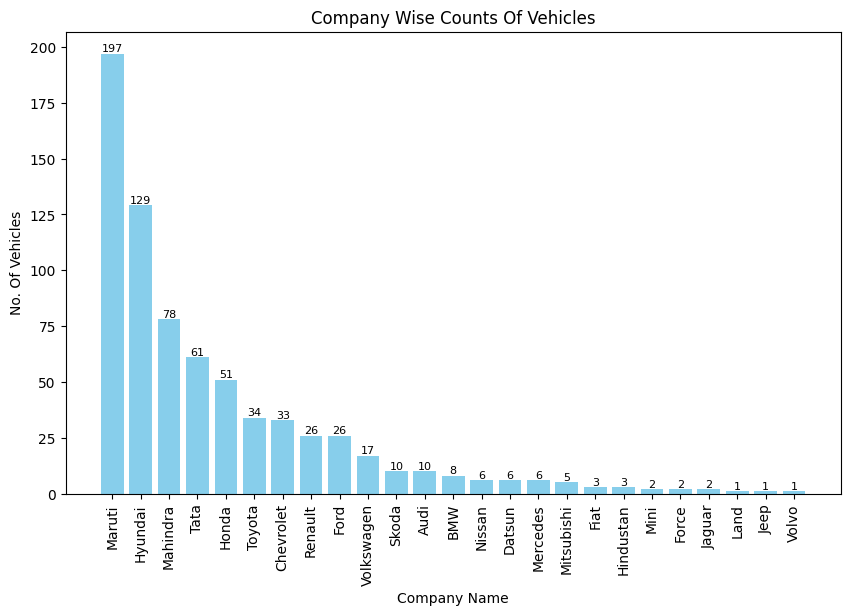

In [33]:
#1 Company wise 
data = df['company'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(data.index,data.values,color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Company Name")
plt.ylabel("No. Of Vehicles")
plt.title('Company Wise Counts Of Vehicles')
for x,y in zip(data.index,data.values):
    plt.text(x,y,y,ha='center',va='bottom',fontsize=8)
plt.show()

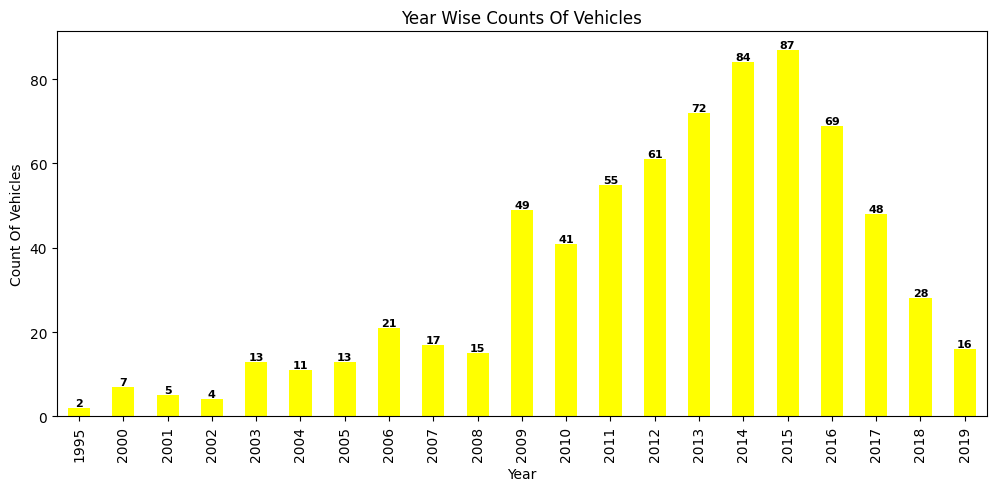

In [34]:
#2 Year wise EDA
data = df['year'].value_counts().sort_index()
ax=data.plot(kind='bar',figsize=(12,5),color='yellow')
ax.bar_label(ax.containers[0],fontsize=8,fontweight='bold')
plt.xlabel("Year")
plt.ylabel('Count Of Vehicles')
plt.title('Year Wise Counts Of Vehicles')
plt.show()

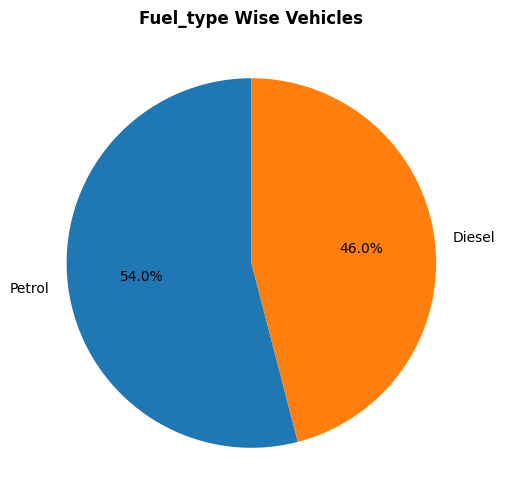

In [35]:
#3 fuel_type wise Graph
data = df['fuel_type'].value_counts()

data.plot(kind="pie",autopct='%1.1f%%',figsize=(6,6),startangle=90)
plt.ylabel('')
plt.title('Fuel_type Wise Vehicles',fontweight='bold')
plt.show()

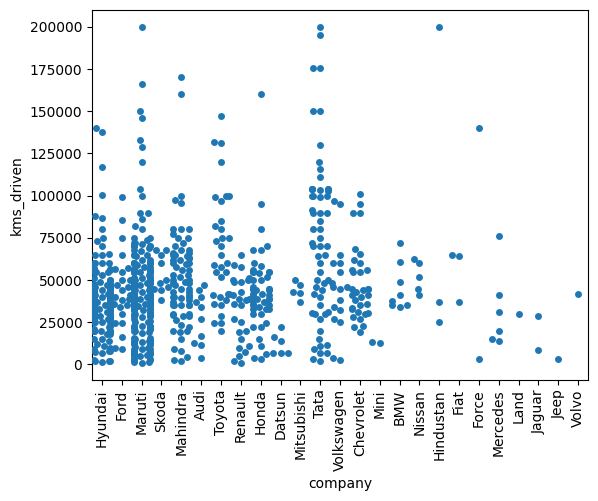

In [36]:
#4 kms_driven Wise Graph
#Keep vehicles running between 1000 and 200000
df=df[(df['kms_driven'] >=1000) & (df['kms_driven'] <=200000)]
sb.swarmplot(x='company',y='kms_driven',data=df)
plt.xticks(rotation=90)
plt.show()

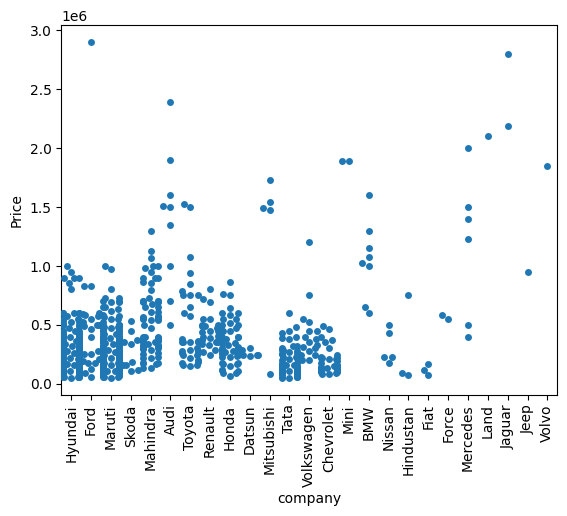

In [37]:
#5 Price Wise Swarm Plot Of Car 
#Keep vehicles Price between 50000 and 2000000
df=df[(df['Price'] >=50000) & (df['Price'] <=3000000)]
sb.swarmplot(x='company',y='Price',data=df)
plt.xticks(rotation=90)
plt.show()

In [38]:
df.reset_index(drop=True,inplace= True)
df.to_csv("clean_data.csv")

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
ds = pd.read_csv('clean_data.csv')
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  685 non-null    int64 
 1   name        685 non-null    object
 2   company     685 non-null    object
 3   year        685 non-null    int64 
 4   Price       685 non-null    int64 
 5   kms_driven  685 non-null    int64 
 6   fuel_type   685 non-null    object
dtypes: int64(4), object(3)
memory usage: 37.6+ KB


In [296]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')

In [59]:
#divide into x and y
x = df[['company','name','year','kms_driven','fuel_type']]
y = df[['Price']]

In [60]:
#Create the pipeline of column Transformer & Model
#Transform string to number and forward to model

In [61]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

In [62]:
ohe = OneHotEncoder()
ohe.fit(x[['company','name','fuel_type']])
ct = make_column_transformer((OneHotEncoder(categories=ohe.categories_), ['company', 'name', 'fuel_type']),remainder='passthrough')
model=LinearRegression()
pipe=make_pipeline(ct,model)

In [63]:
pipe

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
#find the best index use loop
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [76]:
scores = []

for i in range(0,101):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=i)

    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    y_pred = pd.DataFrame(data=y_pred, columns=['Prediction'])
    result = pd.concat([y_test.reset_index(drop=True), y_pred], axis=1)
    score = r2_score(result['Price'], result['Prediction'])
    scores.append(score)
print("Best Score:", max(scores))
print("Best Random State:", scores.index(max(scores)))

Best Score: 0.8197202897744758
Best Random State: 76


In [77]:
scores

[0.6913335724041583,
 0.5295903101979014,
 0.7266948853326465,
 0.7069524765594584,
 0.5307744504743324,
 0.6734590167260665,
 0.6923310020058064,
 0.629933590253456,
 0.7349695895976525,
 0.7614815750801266,
 0.7575548950505901,
 0.42688721389503526,
 0.769570989352806,
 0.7662651125419238,
 0.6326349762941397,
 0.7235575790700043,
 0.5784528678139937,
 0.6245916015596591,
 0.6801352560902313,
 0.7457796443589432,
 0.7238621599696227,
 -0.06833217705803007,
 0.24403671188565612,
 0.6251266993814482,
 0.604721718377942,
 0.6433614172977551,
 0.7699001841351445,
 0.7247928182692372,
 0.7168127688102055,
 0.5467451440968962,
 0.451018618247896,
 0.43685406945622673,
 0.40369153693706517,
 0.5894513147885297,
 0.6855912139280587,
 0.3381805301107772,
 0.5925290581588634,
 0.6231958660403902,
 0.7628002063438517,
 0.7689406907213151,
 0.5847510454368017,
 0.7227723928314194,
 0.6106604634528287,
 0.32037330596901104,
 0.5314860780186366,
 0.7660783077051843,
 0.36216287377842704,
 0.567032

In [67]:
#get index of max value
index=np.argmax(scores)

In [68]:
index

np.int64(76)

In [69]:
#split using best index
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=index)
pipe.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
#use for user input
columns=['company','name','year','kms_driven','fuel_type']
myinput=[['Ford','Figo','2020','50000','Petrol']]
myinput=pd.DataFrame(data=myinput,columns=columns)
result = pipe.predict(myinput)
print("Predicted Price :",round(result[0,0]))

Predicted Price : 473897


In [75]:
# To use in other to export pipe 
#pickle or joblib library
import pickle
pickle.dump(pipe, open('model.pkl', 'wb'))